In [4]:
import setigen as stg
import inspect

print("Setigen version:", stg.__version__)

print("\nTop-level objects:\n")

for name in sorted(dir(stg)):
    if not name.startswith("_"):
        print(name)

print("stg.Frame")
print("\nConstructor:\n")
print(inspect.signature(stg.Frame))

from blimpy import Waterfall

wf = Waterfall("/datag/pipeline/AGBT19B_999_121/blc73_blp03/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.h5")
frame = stg.Frame(waterfall=wf)

Setigen version: 2.7.0

Top-level objects:

Cadence
Frame
OrderedCadence
Spectrum
TimeSeries
absolute_import
array
blimpy_clip
box_f_profile
cadence
cast_value
chi2
constant_bp_profile
constant_path
constant_t_profile
db
dedrift
distributions
division
frame
funcs
fwhm
gaussian
gaussian_f_profile
get_data
get_fs
get_mean_distribution
get_parameter_distributions
get_slice
get_ts
get_value
integrate
lorentzian_f_profile
max_freq
max_norm
min_freq
multiple_gaussian_f_profile
normalize
params_from_backend
periodic_gaussian_t_profile
plot_cadence
plot_frame
plots
print_function
sample_from_obs
sample_gaussian_params
sigma_clip_norm
simple_rfi_path
sinc2_f_profile
sine_path
sine_t_profile
slice
sliding_norm
spectrum
split_array
split_fil
split_utils
split_waterfall_generator
squared_path
timeseries
truncated_gaussian
unit_utils
utils
voigt_f_profile
voltage
waterfall_utils
stg.Frame

Constructor:

(waterfall=None, fchans=None, tchans=None, df=<Quantity 2.79396772 Hz>, dt=<Quantity 18.25361101

In [5]:
from blimpy import Waterfall
import setigen as stg

filename = "/datag/pipeline/AGBT19B_999_121/blc73_blp03/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.h5"

wf = Waterfall(filename, load_data=True)

frame = stg.Frame(waterfall=wf)

print(frame)

In [6]:
from blimpy import Waterfall
import setigen as stg

filename = "/datag/pipeline/AGBT19B_999_121/blc73_blp03/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.h5"

wf = Waterfall(filename, load_data=True)
frame = stg.Frame(waterfall=wf)

print("=== Frame attributes ===")

for name in sorted(dir(frame)):
    if not name.startswith("_"):
        print(name)

=== Frame attributes ===
add_constant_signal
add_metadata
add_noise
add_noise_from_obs
add_signal
ascending
check_waterfall
chi2_df
copy
data
df
dt
fch1
fchans
fmax
fmid
fmin
from_backend_params
from_data
from_waterfall
fs
get_data
get_drift_rate
get_frequency
get_index
get_info
get_intensity
get_metadata
get_noise_stats
get_params
get_slice
get_snr
get_total_stats
get_waterfall
header
load_npy
load_pickle
mean
metadata
mjd
noise_mean
noise_std
obs_length
plot
rng
save_fil
save_h5
save_hdf5
save_npy
save_pickle
shape
source_name
std
t_start
t_stop
tchans
ts
ts_ext
unit_drift_rate
update_metadata
waterfall
zero_data


In [8]:
import inspect
import setigen as stg

print(inspect.signature(stg.Frame.add_signal))
print(inspect.signature(stg.Frame.add_constant_signal))

(self, path, t_profile, f_profile, bp_profile=None, bounding_f_range=None, integrate_path=False, integrate_t_profile=False, integrate_f_profile=False, doppler_smearing=False, t_subsamples=10, f_subsamples=10, smearing_subsamples=10)
(self, f_start, drift_rate, level, width, f_profile_type='sinc2', doppler_smearing=False)


# first insert attempt

In [11]:
from pathlib import Path
import shutil
import numpy as np

from blimpy import Waterfall
import setigen as stg

# ============================================================
# Directories
# ============================================================

BASE = Path("/datax/scratch/wlll2x/carmen_midres")
OUT = BASE / "injected_test"

# ============================================================
# Clean previous injections
# ============================================================

if OUT.exists():
    print(f"Removing old directory: {OUT}")
    shutil.rmtree(OUT)

OUT.mkdir(parents=True)

# ============================================================
# Test cadences
# ============================================================

CADENCES = [
    "cadence_000",
    "cadence_001",
    "cadence_002",
]

# ============================================================
# Injection parameters
# ============================================================

DRIFT_RATE = 0.0          # Hz/s
WIDTH = 2861              # Hz
TARGET_FREQ = 1600.0e6    # Hz

# ============================================================
# Run injection
# ============================================================

for cadence in CADENCES:

    print("=" * 70)
    print(f"Processing {cadence}")
    print("=" * 70)

    lst_file = BASE / cadence / "all.lst"

    if not lst_file.exists():
        print("Missing:", lst_file)
        continue

    files = [
        line.strip()
        for line in lst_file.read_text().splitlines()
        if line.strip()
    ]

    print(f"Found {len(files)} files")

    for i, filename in enumerate(files):

        filename = Path(filename)

        # ----------------------------------------------------
        # Determine ON/OFF
        # ----------------------------------------------------

        inject = (i % 2 == 0)

        if inject:
            status = "ON  -> injecting"
        else:
            status = "OFF -> unchanged"

        print()
        print(filename.name)
        print(status)

        output = OUT / f"{filename.stem}_injected.h5"

        # ----------------------------------------------------
        # OFF scan: copy unchanged
        # ----------------------------------------------------

        if not inject:

            shutil.copy(filename, output)

            print("Copied unchanged:")
            print(output)

            continue

        # ----------------------------------------------------
        # ON scan: inject
        # ----------------------------------------------------

        wf = Waterfall(
            str(filename),
            load_data=True
        )

        frame = stg.Frame(
            waterfall=wf
        )

        # ----------------------------------------------------
        # Detect Setigen frequency units
        # ----------------------------------------------------

        if frame.fmax > 1e7:
            frame_units = "Hz"
            scale = 1e6
        else:
            frame_units = "MHz"
            scale = 1.0

        print("\nDetected Setigen units:", frame_units)

        print(
            f"Frame frequency range: "
            f"{frame.fmin/scale:.6f} - {frame.fmax/scale:.6f} MHz"
        )

        # ----------------------------------------------------
        # Find nearest channel
        # ----------------------------------------------------

        channel = frame.get_index(TARGET_FREQ)
        f_start = frame.get_frequency(channel)

        requested_mhz = TARGET_FREQ / 1e6
        injection_mhz = f_start / scale

        print(f"Requested frequency : {requested_mhz:.6f} MHz")
        print(f"Nearest channel     : {channel}")
        print(f"Injection frequency : {injection_mhz:.6f} MHz")

        # ----------------------------------------------------
        # Injection strength
        # ----------------------------------------------------

        LEVEL = np.std(frame.data) * 1000

        print(f"Injection level: {LEVEL:.3e}")

        before = frame.data.copy()

        signal = frame.add_constant_signal(
            f_start=f_start,
            drift_rate=DRIFT_RATE,
            level=LEVEL,
            width=WIDTH,
        )

        after = frame.data

        diff = after - before

        changed = np.count_nonzero(diff)

        print(f"Signal max      : {signal.max():.3e}")
        print(f"Signal pixels   : {np.count_nonzero(signal)}")
        print(f"Changed pixels  : {changed}")
        print(f"Maximum change  : {diff.max():.3e}")

        if changed == 0:
            print("WARNING: NO PIXELS CHANGED!")

        # ----------------------------------------------------
        # Metadata
        # ----------------------------------------------------

        if frame_units == "Hz":
            injection_hz = float(f_start)
            injection_mhz = float(f_start / 1e6)
        else:
            injection_hz = float(f_start * 1e6)
            injection_mhz = float(f_start)

        frame.add_metadata(
            {
                "injection": True,
                "injection_frequency_Hz": injection_hz,
                "injection_frequency_MHz": injection_mhz,
                "drift_rate_Hz_s": DRIFT_RATE,
                "width_Hz": WIDTH,
                "level": float(LEVEL),
            }
        )

        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        print("Saving:")
        print(output)

        frame.save_hdf5(str(output))

print("\nDONE")

Removing old directory: /datax/scratch/wlll2x/carmen_midres/injected_test
Processing cadence_000
Found 6 files

blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.h5
ON  -> injecting

Detected Setigen units: Hz
Frame frequency range: 1501.466274 - 1688.963413 MHz
Requested frequency : 1600.000000 MHz
Nearest channel     : 34440
Injection frequency : 1599.999905 MHz
Injection level: 6.553e+12
Signal max      : 6.553e+12
Signal pixels   : 279
Changed pixels  : 279
Maximum change  : 6.553e+12
Saving:
/datax/scratch/wlll2x/carmen_midres/injected_test/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5
blimpy.waterfall INFO     __write_to_hdf5_light: Writing the spectra matrix for /datax/scratch/wlll2x/carmen_midres/injected_test/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5 without blobbing.
hdf5plugin._filters WARNING  Deprecation: hdf5plugin.Bitshuffle's lz4 argument is deprecated, use cname='lz4' or 'none' instead.
hdf5plugin._filters WARNING  Deprecation: hdf5p

In [17]:
# ----------------------------------------------------
# Injection strength
# ----------------------------------------------------

LEVEL_MULTIPLIER = 1000

noise_std = np.std(frame.data)

LEVEL = LEVEL_MULTIPLIER * noise_std

print(f"Noise RMS        : {noise_std:.3e}")
print(f"Injection level  : {LEVEL:.3e}")

before = frame.data.copy()

signal = frame.add_constant_signal(
    f_start=f_start,
    drift_rate=DRIFT_RATE,
    level=LEVEL,
    width=WIDTH,
)

after = frame.data

diff = after - before

changed = np.count_nonzero(diff)

print(f"Signal max      : {signal.max():.3e}")
print(f"Signal pixels   : {np.count_nonzero(signal)}")
print(f"Changed pixels  : {changed}")
print(f"Maximum change  : {diff.max():.3e}")

if changed == 0:
    print("WARNING: NO PIXELS CHANGED!")

# ----------------------------------------------------
# Measure injected SNR
# ----------------------------------------------------

signal_peak = np.max(diff)

signal_pixels = diff[diff > 0]

signal_mean = np.mean(signal_pixels)

snr_peak = signal_peak / noise_std
snr_mean = signal_mean / noise_std

print()
print("Measured Injection SNR")
print("----------------------")
print(f"Peak signal      : {signal_peak:.3e}")
print(f"Mean signal      : {signal_mean:.3e}")
print(f"Noise RMS        : {noise_std:.3e}")
print(f"Peak pixel SNR   : {snr_peak:.1f}")
print(f"Mean pixel SNR   : {snr_mean:.1f}")

Noise RMS        : 6.553e+09
Injection level  : 6.553e+12
Signal max      : 6.553e+12
Signal pixels   : 279
Changed pixels  : 279
Maximum change  : 6.553e+12

Measured Injection SNR
----------------------
Peak signal      : 6.553e+12
Mean signal      : 6.553e+12
Noise RMS        : 6.553e+09
Peak pixel SNR   : 1000.0
Mean pixel SNR   : 1000.0


In [15]:
wf = Waterfall(
    "/datag/pipeline/AGBT19B_999_121/blc73_blp03/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.h5",
    load_data=True
)

frame = stg.Frame(waterfall=wf)

print("Before:")
print(frame.data.max())

signal = frame.add_constant_signal(
    f_start=frame.get_frequency(frame.fchans//2),
    drift_rate=0,
    level=100,
    width=5000,
)

print("\nSignal:")
print(signal.max())
print(signal.shape)

print("\nAfter:")
print(frame.data.max())

Before:
4394392700000.0

Signal:
100.0
(279, 65536)

After:
4394392700000.0


In [18]:
before = frame.data.copy()

signal = frame.add_constant_signal(
    f_start=frame.get_frequency(frame.fchans//2),
    drift_rate=0,
    level=100,
    width=5000,
)

print("Before add:")
print(np.count_nonzero(frame.data - before))

frame.data += signal

after = frame.data

print("After manual add:")
print(np.count_nonzero(after - before))

Before add:
0
After manual add:
0


In [20]:
signal = frame.add_constant_signal(
    f_start=frame.get_frequency(frame.fchans//2),
    drift_rate=0,
    level=100,
    width=5000,
)

print("signal dtype:", signal.dtype)
print("frame dtype:", frame.data.dtype)

print("signal min:", signal.min())
print("signal max:", signal.max())

print("nonzero signal pixels:", np.count_nonzero(signal))

print("frame max before:", frame.data.max())

frame.data += signal

print("frame max after:", frame.data.max())

print("difference max:", np.max(frame.data - before))
print("difference nonzero:", np.count_nonzero(frame.data - before))

print("Data statistics:")
print("min:", frame.data.min())
print("max:", frame.data.max())
print("median:", np.median(frame.data))
print("std:", np.std(frame.data))

signal dtype: float64
frame dtype: float32
signal min: 0.0
signal max: 100.0
nonzero signal pixels: 279
frame max before: 4394392700000.0
frame max after: 4394392700000.0
difference max: 0.0
difference nonzero: 0
Data statistics:
min: 3173529300.0
max: 4394392700000.0
median: 10564699000.0
std: 6552821000.0


In [13]:
from blimpy import Waterfall
wf=Waterfall('/datax/scratch/wlll2x/carmen_midres/injected_test/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5', load_data=False)
print(wf.header['fch1'])
print(wf.header['foff'])
print(wf.header['tsamp'])
print(wf.container.selection_shape)


1688.9634132385254
-0.00286102294921875
1.0737418239999998
(279, 1, 65536)


In [5]:
from blimpy import Waterfall

wf = Waterfall(
    "/datax/scratch/wlll2x/carmen_midres/injected_test/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5",
    load_data=False
)

print("Band:")
print("fmin =", wf.container.f_start)
print("fmax =", wf.container.f_stop)

Band:
fmin = 1501.4634132385254
fmax = 1688.9634132385254


# Plot

Original shape : (279, 65536)
Injected shape : (279, 65536)
Maximum difference : 6.553e+12
Changed pixels     : 279
Header fch1 : 1688.963413239 MHz
Header foff : -0.002861022949 MHz/channel
Frequency range : 1501.466274 - 1688.963413 MHz
Peak channel    : 31095
Peak frequency  : 1599.999904633 MHz
Offset from 1600 MHz : -95.4 Hz
Zoom channels : 30995 - 31195
Zoom frequency range : 1599.713802 - 1600.286007 MHz
Integration time : 1.073742 s
Observation time : 299.574 s


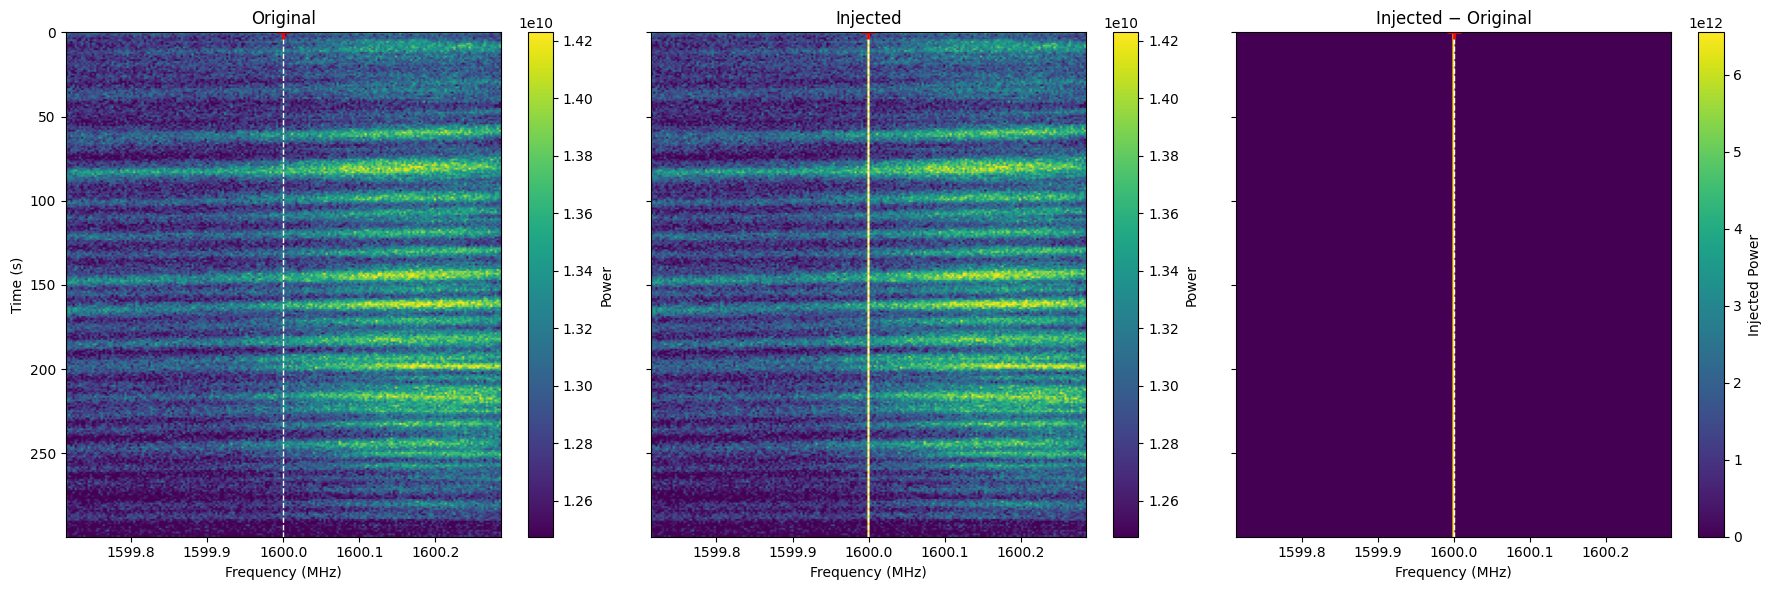

In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from blimpy import Waterfall

# ============================================================
# Files
# ============================================================

original = Path(
    "/datag/pipeline/AGBT19B_999_121/blc73_blp03/"
    "blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.h5"
)

injected = Path(
    "/datax/scratch/wlll2x/carmen_midres/injected_test/"
    "blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5"
)

# ============================================================
# Load
# ============================================================

wf_orig = Waterfall(str(original), load_data=True)
wf_inj = Waterfall(str(injected), load_data=True)

orig = wf_orig.data.squeeze()
inj = wf_inj.data.squeeze()

print(f"Original shape : {orig.shape}")
print(f"Injected shape : {inj.shape}")

# ============================================================
# Difference
# ============================================================

diff = inj - orig

print(f"Maximum difference : {diff.max():.3e}")
print(f"Changed pixels     : {np.count_nonzero(diff)}")

# ============================================================
# Frequency axis (already in MHz)
# ============================================================

fch1 = float(wf_orig.header["fch1"])
foff = float(wf_orig.header["foff"])

nchan = orig.shape[1]

freqs = fch1 + np.arange(nchan, dtype=np.float64) * foff

print(f"Header fch1 : {fch1:.9f} MHz")
print(f"Header foff : {foff:.12f} MHz/channel")
print(f"Frequency range : {freqs.min():.6f} - {freqs.max():.6f} MHz")

# ============================================================
# Locate strongest injected pixel
# ============================================================

time_index, freq_index = np.unravel_index(
    np.nanargmax(diff),
    diff.shape
)

inj_freq = freqs[freq_index]

print(f"Peak channel    : {freq_index}")
print(f"Peak frequency  : {inj_freq:.9f} MHz")
print(f"Offset from 1600 MHz : {(inj_freq-1600.0)*1e6:.1f} Hz")

# ============================================================
# Zoom around injection
# ============================================================

CHANNEL_WINDOW = 100

lo = max(freq_index - CHANNEL_WINDOW, 0)
hi = min(freq_index + CHANNEL_WINDOW + 1, nchan)

orig_zoom = orig[:, lo:hi]
inj_zoom = inj[:, lo:hi]
diff_zoom = diff[:, lo:hi]

freq_zoom = freqs[lo:hi]

if freq_zoom.size == 0:
    raise RuntimeError("Zoom window is empty.")

print(f"Zoom channels : {lo} - {hi-1}")
print(
    f"Zoom frequency range : "
    f"{freq_zoom.min():.6f} - {freq_zoom.max():.6f} MHz"
)

# ============================================================
# Make frequency increase left -> right
# ============================================================

if freq_zoom[0] > freq_zoom[-1]:
    freq_zoom = freq_zoom[::-1]
    orig_zoom = orig_zoom[:, ::-1]
    inj_zoom = inj_zoom[:, ::-1]
    diff_zoom = diff_zoom[:, ::-1]

# ============================================================
# Display scaling
# ============================================================

vmin = np.percentile(orig_zoom, 5)
vmax = np.percentile(orig_zoom, 99.9)

positive = diff_zoom[diff_zoom > 0]

if positive.size > 0:
    diff_vmax = np.percentile(positive, 99)
else:
    diff_vmax = diff_zoom.max()

# ============================================================
# Time axis
# ============================================================

dt = float(wf_orig.header["tsamp"])
obs_time = orig.shape[0] * dt

print(f"Integration time : {dt:.6f} s")
print(f"Observation time : {obs_time:.3f} s")

extent = [
    freq_zoom[0],
    freq_zoom[-1],
    obs_time,
    0,
]

peak_time = time_index * dt

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    sharey=True,
)

# ------------------------------------------------------------
# Original
# ------------------------------------------------------------

im0 = axes[0].imshow(
    orig_zoom,
    aspect="auto",
    origin="upper",
    extent=extent,
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title("Original")
axes[0].set_xlabel("Frequency (MHz)")
axes[0].set_ylabel("Time (s)")

plt.colorbar(im0, ax=axes[0], label="Power")

# ------------------------------------------------------------
# Injected
# ------------------------------------------------------------

im1 = axes[1].imshow(
    inj_zoom,
    aspect="auto",
    origin="upper",
    extent=extent,
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title("Injected")
axes[1].set_xlabel("Frequency (MHz)")

plt.colorbar(im1, ax=axes[1], label="Power")

# ------------------------------------------------------------
# Difference
# ------------------------------------------------------------

im2 = axes[2].imshow(
    diff_zoom,
    aspect="auto",
    origin="upper",
    extent=extent,
    vmin=0,
    vmax=diff_vmax,
)

axes[2].set_title("Injected − Original")
axes[2].set_xlabel("Frequency (MHz)")

plt.colorbar(im2, ax=axes[2], label="Injected Power")

# ============================================================
# Mark detected injection
# ============================================================

for ax in axes:
    ax.axvline(
        inj_freq,
        color="white",
        linestyle="--",
        linewidth=1,
    )

    ax.plot(
        inj_freq,
        peak_time,
        marker="+",
        color="red",
        markersize=10,
        markeredgewidth=2,
    )

plt.tight_layout()
plt.show()

In [4]:
nchan = orig.shape[1]

freqs = fch1 + np.arange(nchan, dtype=np.float64) * foff

print("First frequency :", freqs[0])
print("Last frequency  :", freqs[-1])
print("Min frequency   :", freqs.min())
print("Max frequency   :", freqs.max())

time_index, freq_index = np.unravel_index(np.argmax(diff), diff.shape)

print("Peak channel:", freq_index)
print("Peak frequency:", freqs[freq_index])

First frequency : 1688.9634132385254
Last frequency  : 1501.4662742614746
Min frequency   : 1501.4662742614746
Max frequency   : 1688.9634132385254
Peak channel: 31095
Peak frequency: 1599.9999046325684


In [5]:
from blimpy import Waterfall

wf = Waterfall(
    "/datax/scratch/wlll2x/carmen_midres/injected_test/"
    "blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5",
    load_data=True
)

print("fch1 =", wf.header["fch1"])
print("foff =", wf.header["foff"])
print("data shape =", wf.data.shape)

fch1 = 1688.9634132385254
foff = -0.00286102294921875
data shape = (279, 1, 65536)


In [18]:
from blimpy import Waterfall
import numpy as np

orig = Waterfall(
    "/datag/pipeline/AGBT19B_999_121/blc73_blp03/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.h5"
)

inj = Waterfall(
    "/datax/scratch/wlll2x/carmen_midres/injected_test/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5"
)

diff = inj.data - orig.data

print("Maximum difference:", np.max(diff))
print("Minimum difference:", np.min(diff))
print("Number of changed pixels:", np.count_nonzero(diff))

Maximum difference: 6552821400000.0
Minimum difference: 0.0
Number of changed pixels: 279


# Plot injected cadence

H5: 18
DAT: 18

CADENCE 000
Scale: 86.81251 93.89074

 blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5
     Corrected_Frequency  Drift_Rate            SNR
672          1600.001340    9.584659  169768.281250
671          1600.001330   -9.584659  169767.328125
674          1600.001351   28.753978  112777.031250
673          1599.998459  -28.753978  112776.718750
675          1600.001351   28.753978   56998.269531

 blc73_guppi_58832_09084_NGC7640_0035.gpuspec.0002_injected.h5
     Corrected_Frequency  Drift_Rate           SNR
639          1599.995598  -28.753978  75766.234375

 blc73_guppi_58832_09716_NGC7640_0037.gpuspec.0002_injected.h5
     Corrected_Frequency  Drift_Rate           SNR
656          1600.027079   -9.584659  91705.562500
695          1599.998459  -28.753978  60925.722656


/tmp/ipykernel_2948529/1091032579.py:478: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


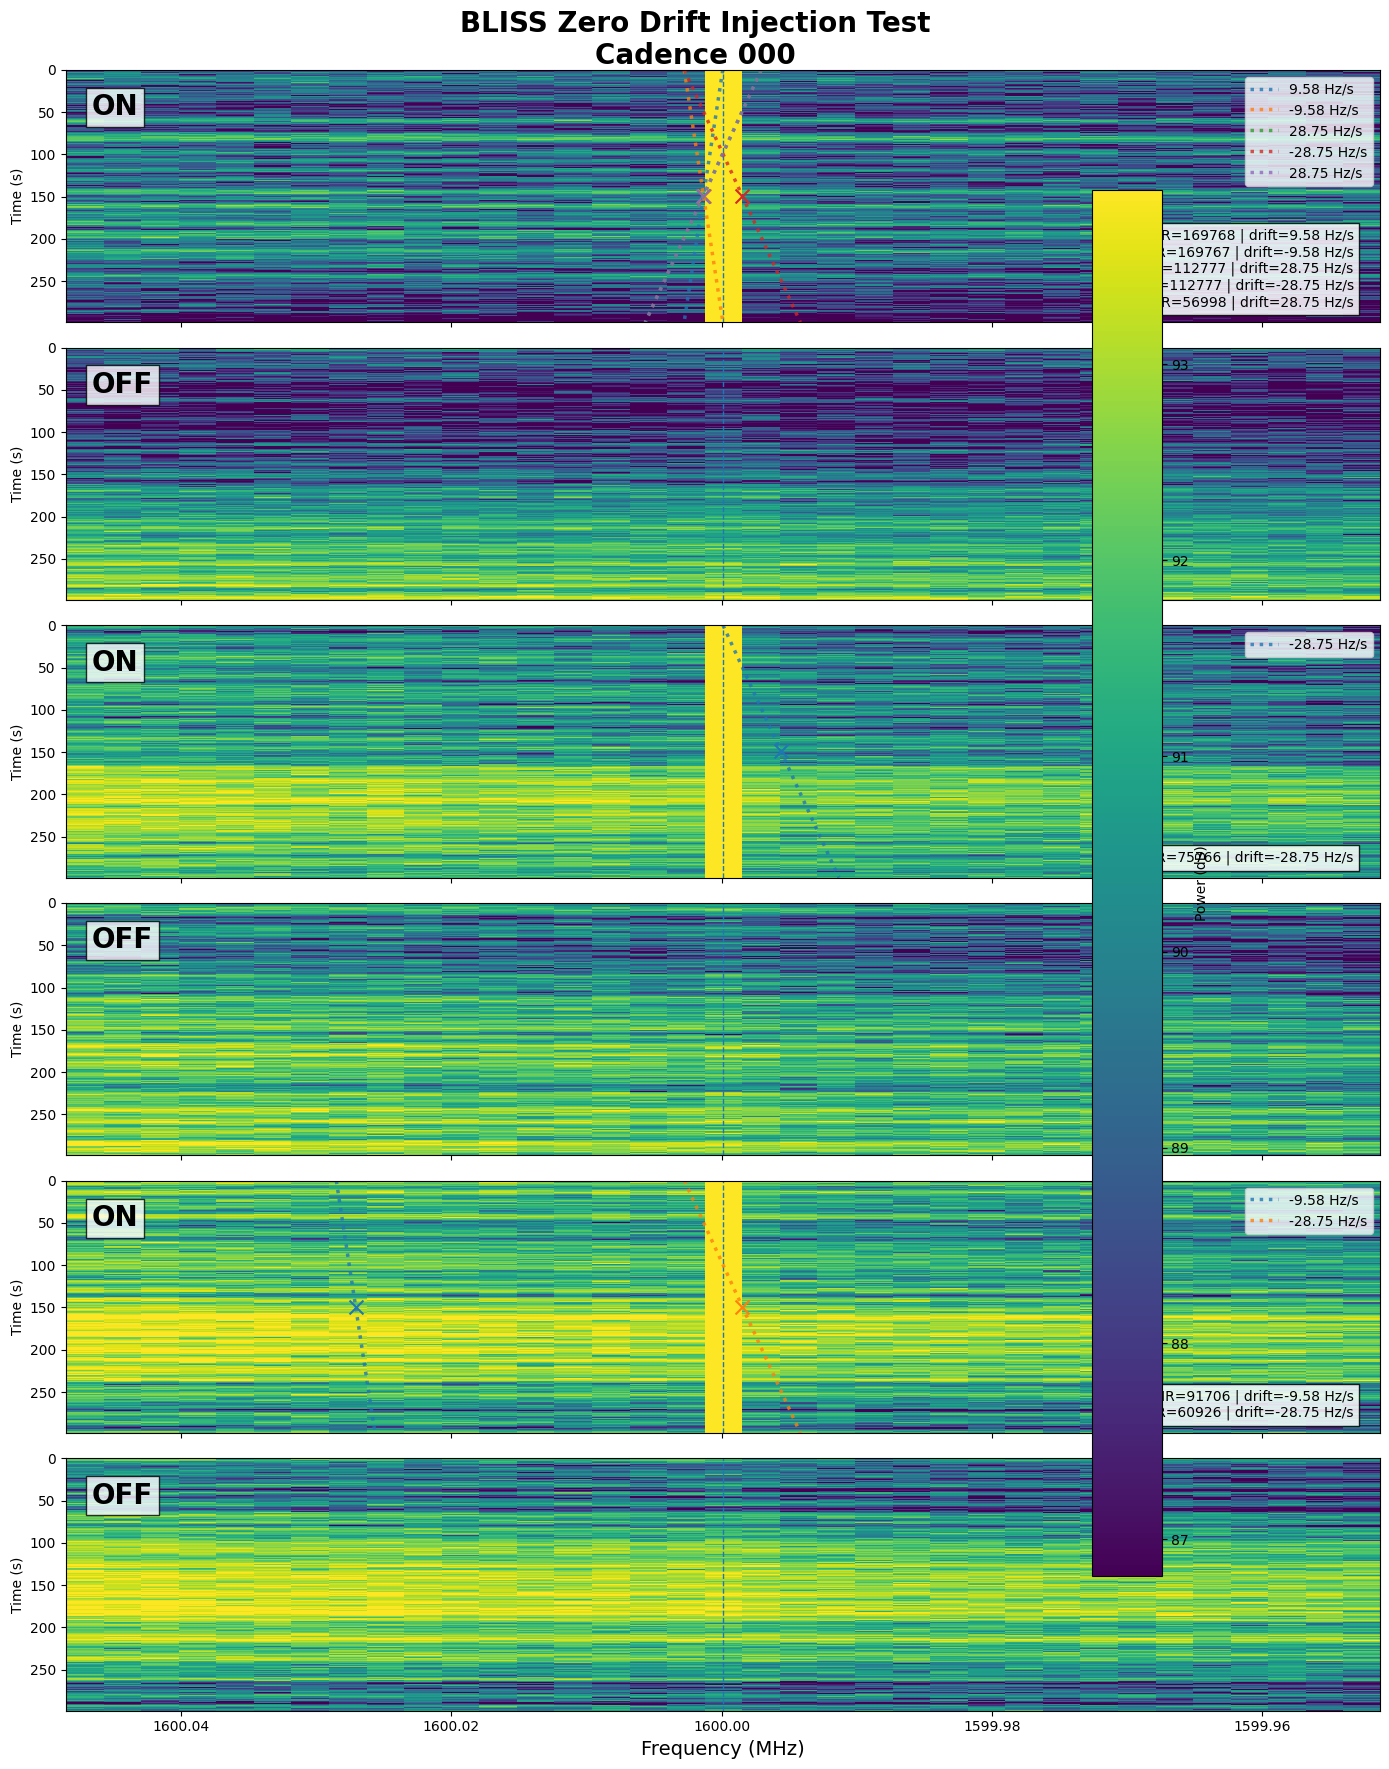


CADENCE 001
Scale: 89.35838 95.55089

 blc73_guppi_58832_10405_NGC0185_0039.gpuspec.0002_injected.h5
     Corrected_Frequency  Drift_Rate           SNR
249          1600.027079   -9.584659  61175.562500
274          1599.992737  -28.753978  40647.765625

 blc73_guppi_58832_11033_NGC0185_0041.gpuspec.0002_injected.h5
     Corrected_Frequency  Drift_Rate           SNR
131          1600.001330   -9.584659  59958.082031
150          1599.998459  -28.753978  39836.800781

 blc73_guppi_58832_11671_NGC0185_0043.gpuspec.0002_injected.h5
     Corrected_Frequency  Drift_Rate           SNR
185          1600.032801   -9.584659  94521.351562
193          1599.995598  -28.753978  62797.816406


/tmp/ipykernel_2948529/1091032579.py:478: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


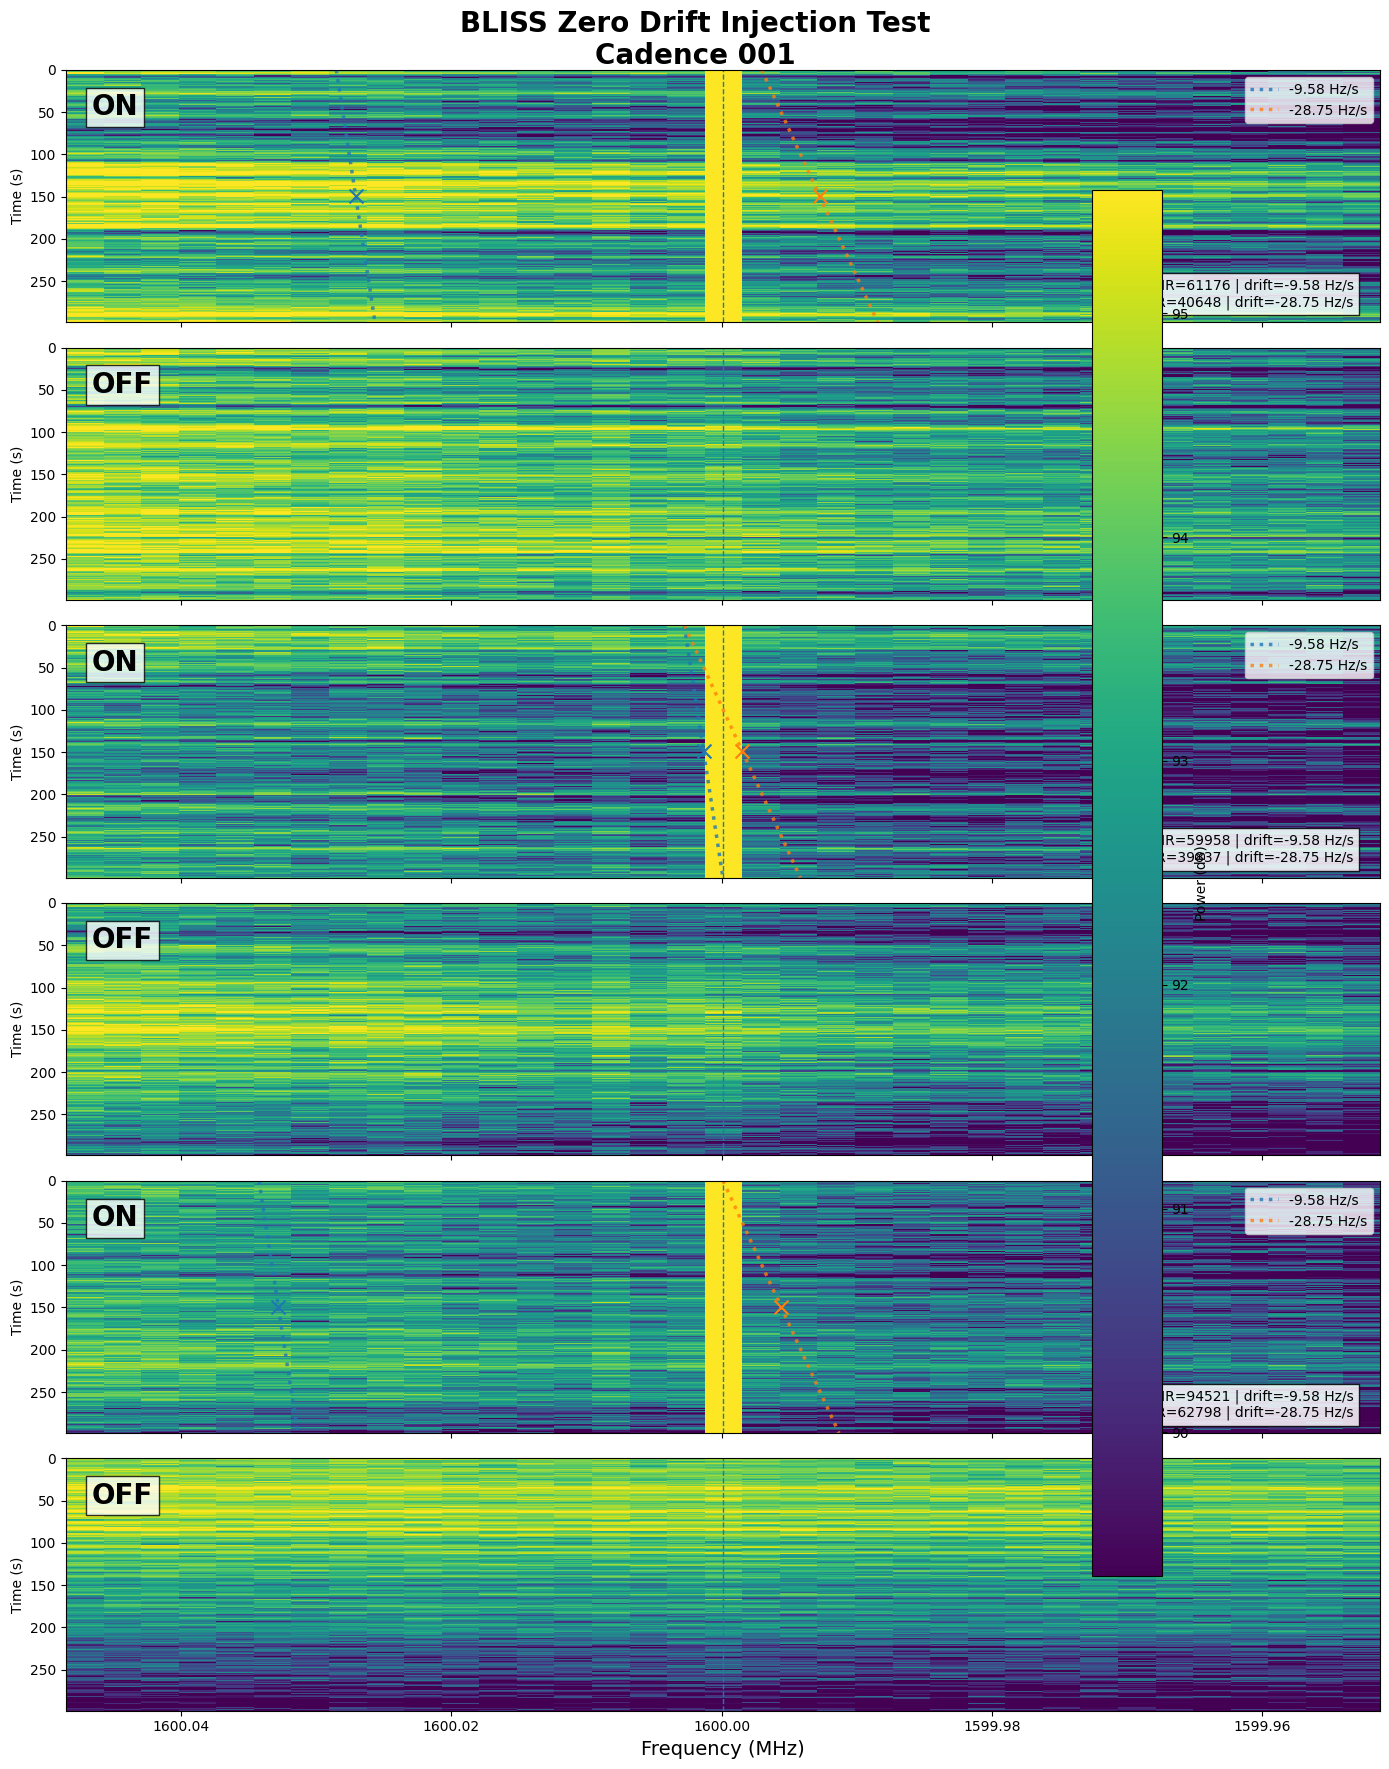


CADENCE 002
Scale: 86.97069 96.44304

 blc73_guppi_58832_12338_And_X_0045.gpuspec.0002_injected.h5
     Corrected_Frequency  Drift_Rate           SNR
332          1600.001330   -9.584659  50995.617188
335          1600.001340    9.584659  50994.984375
336          1599.998459  -28.753978  33878.902344
339          1600.001351   28.753978  33878.109375
340          1600.001351   28.753978  17125.531250

 blc73_guppi_58832_12978_And_X_0047.gpuspec.0002_injected.h5
     Corrected_Frequency  Drift_Rate           SNR
640          1600.001340    9.584659  38166.457031
629          1600.001330   -9.584659  38166.410156
665          1600.001351   28.753978  25350.832031
672          1599.998459  -28.753978  25350.742188
666          1600.001351   28.753978  12807.580078

 blc73_guppi_58832_13616_And_X_0049.gpuspec.0002_injected.h5
     Corrected_Frequency  Drift_Rate          SNR
159          1600.001330   -9.584659  3380.058838
160          1600.001340    9.584659  3380.007812
163          1

/tmp/ipykernel_2948529/1091032579.py:478: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


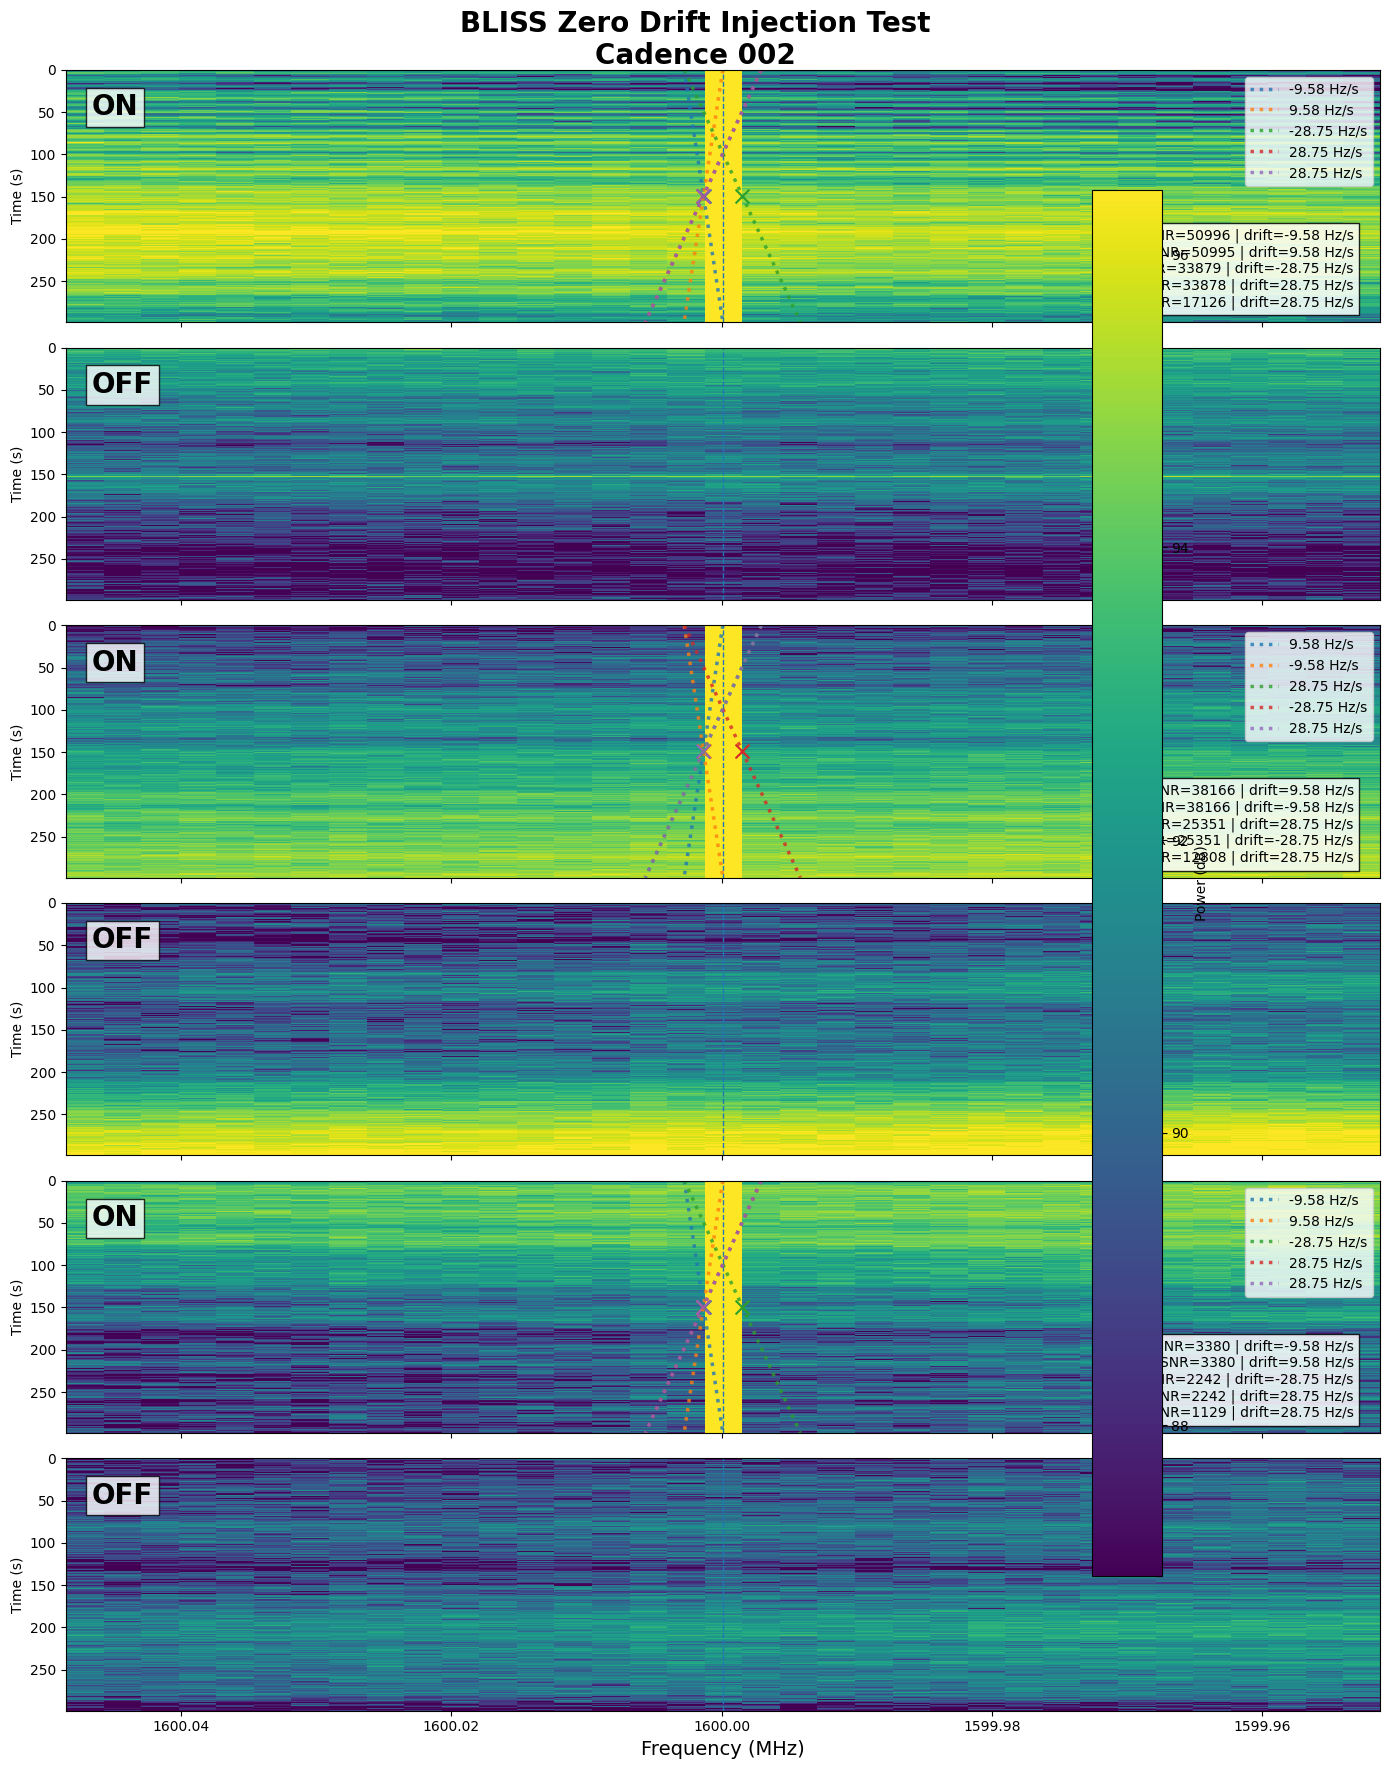

In [13]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from blimpy import Waterfall


# ==========================================================
# Paths
# ==========================================================

H5_DIR = Path(
    "/datax/scratch/wlll2x/carmen_midres/injected_test"
)

DAT_DIR = Path(
    "/datax/scratch/wlll2x/carmen_midres_bliss_injected_combined"
)


# ==========================================================
# Parameters
# ==========================================================

target_freq = 1600.0   # MHz
zoom_MHz = 0.05
FILES_PER_CADENCE = 6



# ==========================================================
# BLISS parser
# ==========================================================

def read_bliss_dat(filename):

    tables = []

    with open(filename, "r") as f:
        header = None
        rows = []

        for line in f:

            clean = line.strip()

            if clean.startswith("#"):
                clean = clean[1:].strip()

            if "Top_Hit" in clean and "SNR" in clean:

                if header and rows:
                    tables.append(
                        pd.DataFrame(rows, columns=header)
                    )

                header = clean.split()
                rows = []
                continue


            if clean.startswith("-"):
                continue


            if header and clean and clean[0].isdigit():

                vals = clean.split()[:len(header)]

                if len(vals) == len(header):
                    rows.append(vals)


    if header and rows:

        tables.append(
            pd.DataFrame(rows, columns=header)
        )


    if not tables:
        return None


    hits = pd.concat(
        tables,
        ignore_index=True
    )


    for c in hits.columns:
        hits[c] = pd.to_numeric(
            hits[c],
            errors="coerce"
        )

    return hits



# ==========================================================
# Files
# ==========================================================

h5_files = sorted(
    H5_DIR.glob("*_injected.h5")
)

dat_files = sorted(
    DAT_DIR.glob("*_combined.dat")
)


print("H5:", len(h5_files))
print("DAT:", len(dat_files))


# ==========================================================
# Plot cadences
# ==========================================================

for cadence in range(3):

    print("\n" + "="*60)
    print(f"CADENCE {cadence:03d}")
    print("="*60)


    start = cadence * FILES_PER_CADENCE
    end = start + FILES_PER_CADENCE


    cadence_h5 = h5_files[start:end]
    cadence_dat = dat_files[start:end]



    # ------------------------------------------------------
    # OFF-only scaling
    # ------------------------------------------------------

    off_pixels = []


    for j, h5 in enumerate(cadence_h5):

        if j % 2 == 1:

            wf = Waterfall(
                str(h5),
                load_data=True
            )

            data = np.squeeze(
                wf.data
            )


            freqs = (
                float(wf.header["fch1"])
                +
                np.arange(data.shape[1])
                *
                float(wf.header["foff"])
            )


            mask = (
                (freqs > target_freq-zoom_MHz)
                &
                (freqs < target_freq+zoom_MHz)
            )


            crop = data[:,mask]


            image = 10*np.log10(
                crop - crop.min() + 1
            )


            off_pixels.extend(
                image.flatten()
            )



    off_pixels = np.array(off_pixels)


    vmin = np.percentile(
        off_pixels,
        5
    )

    vmax = np.percentile(
        off_pixels,
        99
    )


    print(
        "Scale:",
        vmin,
        vmax
    )



    fig, axes = plt.subplots(
        6,
        1,
        figsize=(14,18),
        sharex=True
    )



    # ------------------------------------------------------
    # Individual scans
    # ------------------------------------------------------

    for i, (ax, h5, dat) in enumerate(
        zip(
            axes,
            cadence_h5,
            cadence_dat
        )
    ):


        wf = Waterfall(
            str(h5),
            load_data=True
        )


        data = np.squeeze(
            wf.data
        )


        freqs = (
            float(wf.header["fch1"])
            +
            np.arange(data.shape[1])
            *
            float(wf.header["foff"])
        )


        inj_idx = np.argmin(
            abs(freqs-target_freq)
        )

        inj_freq = freqs[inj_idx]


        mask = (
            (freqs > target_freq-zoom_MHz)
            &
            (freqs < target_freq+zoom_MHz)
        )


        crop = data[:,mask]

        crop_freqs = freqs[mask]


        image = 10*np.log10(
            crop - crop.min() + 1
        )


        times = (
            np.arange(data.shape[0])
            *
            float(wf.header["tsamp"])
        )


        # --------------------------------------------------
        # Waterfall
        # --------------------------------------------------

        im = ax.imshow(
            image,
            aspect="auto",
            origin="upper",
            interpolation="none",
            extent=[
                crop_freqs.max(),
                crop_freqs.min(),
                times[-1],
                times[0]
            ],
            vmin=vmin,
            vmax=vmax
        )


        ax.axvline(
            inj_freq,
            linestyle="--",
            linewidth=1
        )



        # --------------------------------------------------
        # BLISS
        # --------------------------------------------------

        hits = read_bliss_dat(dat)


        if hits is not None:

            nearby = hits[
                abs(
                    hits["Corrected_Frequency"]
                    -
                    target_freq
                )
                <
                zoom_MHz
            ].sort_values(
                "SNR",
                ascending=False
            )


            if len(nearby):

                print("\n", h5.name)

                print(
                    nearby[
                        [
                            "Corrected_Frequency",
                            "Drift_Rate",
                            "SNR"
                        ]
                    ]
                )


                for _, row in nearby.iterrows():

                    freq0 = row["Corrected_Frequency"]

                    drift = (
                        row["Drift_Rate"]
                        /
                        1e6
                    )


                    drift_track = (
                        freq0
                        +
                        drift *
                        (
                            times
                            -
                            times[len(times)//2]
                        )
                    )


                    ax.plot(
                        drift_track,
                        times,
                        ":",
                        linewidth=2.5,
                        alpha=0.8,
                        label=
                        f"{row['Drift_Rate']:.2f} Hz/s"
                    )


                    ax.scatter(
                        freq0,
                        times[len(times)//2],
                        marker="x",
                        s=100
                    )



                # --------------------------------------------------
                # Single non-overlapping BLISS summary box
                # --------------------------------------------------

                label_lines = []

                for _, row in nearby.iterrows():

                    label_lines.append(
                        f"SNR={row['SNR']:.0f} | "
                        f"drift={row['Drift_Rate']:.2f} Hz/s"
                    )


                label_text = "\n".join(
                    label_lines
                )


                ax.text(
                    0.98,
                    0.05,
                    label_text,
                    transform=ax.transAxes,
                    ha="right",
                    va="bottom",
                    fontsize=10,
                    bbox=dict(
                        facecolor="white",
                        alpha=0.85
                    )
                )

                ax.legend(
                    fontsize=10
                )



        # --------------------------------------------------
        # Labels
        # --------------------------------------------------

        ax.text(
            0.02,
            0.82,
            "ON" if i % 2 == 0 else "OFF",
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                alpha=0.8
            )
        )


        ax.set_ylabel(
            "Time (s)"
        )


    axes[-1].set_xlabel(
        "Frequency (MHz)",
        fontsize=14
    )


    fig.colorbar(
        im,
        ax=axes,
        label="Power (dB)"
    )


    plt.suptitle(
        f"BLISS Zero Drift Injection Test\nCadence {cadence:03d}",
        fontsize=20,
        fontweight="bold"
    )


    plt.tight_layout()

    plt.show()

In [ ]:
from pathlib import Path
import pandas as pd


# ==========================================================
# Pick a BLISS .dat file
# ==========================================================

DAT_DIR = Path(
    "/datax/scratch/wlll2x/carmen_midres_bliss_injected_combined"
)


dat_files = sorted(
    DAT_DIR.glob("*.dat")
)


print(f"Found {len(dat_files)} dat files\n")


for i, f in enumerate(dat_files[:10]):
    print(i, f.name)


# ==========================================================
# Select first file
# ==========================================================

dat_file = dat_files[0]

print("\n======================================")
print("Testing:")
print(dat_file)
print("======================================\n")


# ==========================================================
# Print raw contents
# ==========================================================

print("FIRST 30 LINES")
print("--------------------------------------")


with open(dat_file, "r") as f:

    for i, line in enumerate(f):

        print(
            f"{i:03d}: {repr(line)}"
        )

        if i >= 29:
            break


# ==========================================================
# Try different pandas strategies
# ==========================================================

print("\n\n======================================")
print("Attempt 1: whitespace parser")
print("======================================")

try:

    df = pd.read_csv(
        dat_file,
        sep=r"\s+",
        engine="python"
    )

    print("SUCCESS")

    print(
        df.head()
    )

    print(
        df.columns
    )


except Exception as e:

    print("FAILED")
    print(e)



print("\n\n======================================")
print("Attempt 2: ignore # comments")
print("======================================")


try:

    df = pd.read_csv(
        dat_file,
        sep=r"\s+",
        engine="python",
        comment="#"
    )


    print("SUCCESS")

    print(
        df.head()
    )

    print(
        df.columns
    )


except Exception as e:

    print("FAILED")
    print(e)



print("\n\n======================================")
print("Attempt 3: python engine + skip bad lines")
print("======================================")


try:

    df = pd.read_csv(
        dat_file,
        sep=r"\s+",
        engine="python",
        on_bad_lines="skip"
    )


    print("SUCCESS")

    print(
        df.head()
    )

    print(
        df.columns
    )


except Exception as e:

    print("FAILED")
    print(e)



Found 18 dat files

0 blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected_combined.dat
1 blc73_guppi_58832_08767_HIP115723_0034.gpuspec.0002_injected_combined.dat
2 blc73_guppi_58832_09084_NGC7640_0035.gpuspec.0002_injected_combined.dat
3 blc73_guppi_58832_09400_HIP115106_0036.gpuspec.0002_injected_combined.dat
4 blc73_guppi_58832_09716_NGC7640_0037.gpuspec.0002_injected_combined.dat
5 blc73_guppi_58832_10034_HIP115708_0038.gpuspec.0002_injected_combined.dat
6 blc73_guppi_58832_10405_NGC0185_0039.gpuspec.0002_injected_combined.dat
7 blc73_guppi_58832_10719_HIP2860_0040.gpuspec.0002_injected_combined.dat
8 blc73_guppi_58832_11033_NGC0185_0041.gpuspec.0002_injected_combined.dat
9 blc73_guppi_58832_11352_HIP2514_0042.gpuspec.0002_injected_combined.dat

Testing:
/datax/scratch/wlll2x/carmen_midres_bliss_injected_combined/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected_combined.dat

FIRST 30 LINES
--------------------------------------
000: '# -------------------------- o 

In [2]:
from pathlib import Path

dat_file = Path(
    "/datax/scratch/wlll2x/carmen_midres_bliss_injected_combined/"
    "blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected_combined.dat"
)

with open(dat_file, "r") as f:
    for i in range(40):
        print(f"{i:03d}: {f.readline().rstrip()}")

000: # -------------------------- o --------------------------
001: # File ID: /datax/scratch/wlll2x/carmen_midres/injected_test/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5
002: # -------------------------- o --------------------------
003: # Source:NGC7640
004: # MJD: 58832.09780092593	RA: 23h22m06.552ss	DEC:+40d50m43.44s
005: # DELTAT: 1.073742	DELTAF(Hz):  -2861.022949	max_drift_rate: 28.7539776	obs_length: 299.573969
006: # --------------------------
007: # Top_Hit_#	Drift_Rate	SNR	Uncorrected_Frequency	Corrected_Frequency	Index	freq_start	freq_end	SEFD_freq	Coarse_Channel_Number	Full_number_of_hits
008: # --------------------------
009: 000001	9.584659	98.356880	1687.500005	1687.500005	513	1687.498569	1687.501441	0.000000	0.000000	0	3
010: 000002	0.000000	201.782806	1687.498569	1687.498569	512	1687.498569	1687.498569	0.000000	0.000000	0	2
011: 000003	-28.753978	64.338753	1687.497124	1687.497124	510	1687.501431	1687.492817	0.000000	0.000000	0	4
012: 000004	28.7539

In [4]:
def read_bliss_dat(filename):

    """
    Reads concatenated BLISS .dat files.
    Handles extra columns in BLISS output.
    """

    tables = []

    with open(filename, "r") as f:
        lines = f.readlines()


    header = None
    rows = []


    for line in lines:

        clean = line.strip()


        if clean.startswith("#"):
            clean = clean[1:].strip()


        # Find header

        if (
            "Top_Hit" in clean
            and
            "SNR" in clean
        ):

            if header is not None and rows:

                tables.append(
                    pd.DataFrame(
                        rows,
                        columns=header
                    )
                )


            header = clean.split()

            rows = []

            continue



        if clean.startswith("-"):
            continue



        if (
            header is not None
            and clean
            and clean[0].isdigit()
        ):

            values = clean.split()


            # BLISS sometimes has extra columns
            values = values[:len(header)]


            # only accept valid rows

            if len(values) == len(header):

                rows.append(values)



    # final block

    if header is not None and rows:

        tables.append(
            pd.DataFrame(
                rows,
                columns=header
            )
        )



    if not tables:
        return None



    hits = pd.concat(
        tables,
        ignore_index=True
    )


    # convert numbers

    for col in hits.columns:

        hits[col] = pd.to_numeric(
            hits[col],
            errors="coerce"
        )


    return hits

# extract coarse

In [14]:
from blimpy import Waterfall
import numpy as np

filename = "/datax/scratch/wlll2x/carmen_midres/injected_test/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5"

wf = Waterfall(filename, load_data=False)

fch1 = float(wf.header["fch1"])
foff = float(wf.header["foff"])

target_freq = 1600.0  # MHz

channel = int(round((target_freq - fch1) / foff))
coarse = channel // 1024

print("Target channel:", channel)
print("Coarse channel:", coarse)
print("Channel within coarse:", channel % 1024)

Target channel: 31095
Coarse channel: 30
Channel within coarse: 375


In [16]:
import h5py
import os
import glob

# ==========================================================
# Input / Output
# ==========================================================

indir = "/datax/scratch/wlll2x/carmen_midres/injected_test"
outdir = "/datax/scratch/wlll2x/seticore_test"

os.makedirs(outdir, exist_ok=True)

# ==========================================================
# Injection coarse channel
# ==========================================================

COARSE = 30
NFPC = 1024

start = COARSE * NFPC
stop = (COARSE + 1) * NFPC

print(f"Extracting coarse channel {COARSE}")
print(f"Channels {start} : {stop-1}")

# ==========================================================
# Extract each injected file
# ==========================================================

for filename in sorted(glob.glob(os.path.join(indir, "*.h5"))):

    print("\n=======================================")
    print("Processing:", os.path.basename(filename))
    print("=======================================")

    outfile = os.path.join(
        outdir,
        os.path.basename(filename).replace(
            ".h5",
            f"_coarse{COARSE}.h5"
        )
    )

    with h5py.File(filename, "r") as fin:
        with h5py.File(outfile, "w") as fout:

            # --------------------------------------------------
            # Copy root attributes
            # --------------------------------------------------

            for key, val in fin.attrs.items():
                fout.attrs[key] = val

            # --------------------------------------------------
            # Crop data
            # --------------------------------------------------

            data = fin["data"][:, :, start:stop]

            d = fout.create_dataset(
                "data",
                data=data,
                dtype=fin["data"].dtype
            )

            # Copy all existing attributes
            for key, val in fin["data"].attrs.items():
                d.attrs[key] = val

            # --------------------------------------------------
            # Update metadata
            # --------------------------------------------------

            d.attrs["nchans"] = NFPC
            d.attrs["nfpc"] = NFPC

            d.attrs["fch1"] = (
                fin["data"].attrs["fch1"]
                +
                start * fin["data"].attrs["foff"]
            )

            print("New fch1:", d.attrs["fch1"])
            print("nchans :", d.attrs["nchans"])
            print("nfpc   :", d.attrs["nfpc"])

            # --------------------------------------------------
            # Copy mask if present
            # --------------------------------------------------

            if "mask" in fin:

                mask = fin["mask"][:, :, start:stop]

                m = fout.create_dataset(
                    "mask",
                    data=mask
                )

                for key, val in fin["mask"].attrs.items():
                    m.attrs[key] = val

    print("Saved:", outfile)

print("\n=======================================")
print("Finished extracting coarse channel 30")
print("=======================================")

Extracting coarse channel 30
Channels 30720 : 31743

Processing: blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected.h5
New fch1: 1601.0727882385254
nchans : 1024
nfpc   : 1024
Saved: /datax/scratch/wlll2x/seticore_test/blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002_injected_coarse30.h5

Processing: blc73_guppi_58832_08767_HIP115723_0034.gpuspec.0002_injected.h5
New fch1: 1601.0727882385254
nchans : 1024
nfpc   : 1024
Saved: /datax/scratch/wlll2x/seticore_test/blc73_guppi_58832_08767_HIP115723_0034.gpuspec.0002_injected_coarse30.h5

Processing: blc73_guppi_58832_09084_NGC7640_0035.gpuspec.0002_injected.h5
New fch1: 1601.0727882385254
nchans : 1024
nfpc   : 1024
Saved: /datax/scratch/wlll2x/seticore_test/blc73_guppi_58832_09084_NGC7640_0035.gpuspec.0002_injected_coarse30.h5

Processing: blc73_guppi_58832_09400_HIP115106_0036.gpuspec.0002_injected.h5
New fch1: 1601.0727882385254
nchans : 1024
nfpc   : 1024
Saved: /datax/scratch/wlll2x/seticore_test/blc73_guppi_58832_09400_HIP11

# voyager h5 editing

In [18]:
import h5py

src = "/datag/public/voyager_2020/spliced_blc00010203040506o7o0111213141516o7o021222324252627_guppi_59046_80036_DIAG_VOYAGER-1_0011.rawspec.0002.h5"

dst = "/datax/scratch/wlll2x/seticore_test/voyager_0011_fixed.h5"


with h5py.File(src, "r") as fin:
    with h5py.File(dst, "w") as fout:

        # root attributes
        for key, val in fin.attrs.items():
            fout.attrs[key] = val

        # data
        d = fout.create_dataset(
            "data",
            data=fin["data"][:],
            dtype=fin["data"].dtype
        )

        for key, val in fin["data"].attrs.items():
            d.attrs[key] = val

        # seticore requirement
        d.attrs["nfpc"] = 1024
        d.attrs["nchans"] = 1155072

        # mask
        if "mask" in fin:

            m = fout.create_dataset(
                "mask",
                data=fin["mask"][:]
            )

            for key, val in fin["mask"].attrs.items():
                m.attrs[key] = val


print("Saved:", dst)

Saved: /datax/scratch/wlll2x/seticore_test/voyager_0011_fixed.h5
